In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms, datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Cihaz yapılandırması (GPU mevcutsa kullan)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")

Kullanılan Cihaz: cuda


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dir = r'C:\Users\efeya\Desktop\DerinFinal\Data\archive\train'
val_dir = r'C:\Users\efeya\Desktop\DerinFinal\Data\archive\test'

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
print(f"Sınıflar başarıyla tanımlandı: {classes}")
print(f"Eğitim görseli sayısı: {len(train_dataset)}")
print(f"Doğrulama görseli sayısı: {len(val_dataset)}")

Sınıflar başarıyla tanımlandı: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
Eğitim görseli sayısı: 28709
Doğrulama görseli sayısı: 7178


In [ ]:
def build_model(num_classes=7):
    model = models.squeezenet1_1(weights='DEFAULT')
    
    model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
    model.num_classes = num_classes
    
    return model.to(device)

model = build_model(num_classes=7)

In [ ]:
import torch.optim as optim

history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}

optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

best_v_acc = 0.0 
epochs = 20

print("Eğitim Başladı (Metrik Takibi Aktif)...")
print("-" * 50)

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = validate(model, val_loader, criterion)
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    scheduler.step(v_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    checkpoint_msg = ""
    if v_acc > best_v_acc:
        best_v_acc = v_acc
        torch.save(model.state_dict(), 'best_squeezenet_emotion.pth')
        checkpoint_msg = " --> [KAYDEDİLDİ: En İyi Model]"
    
    print(f"Epoch {epoch+1:02d}/{epochs} | LR: {current_lr:.6f}")
    print(f"Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f}")
    print(f"Train Acc: %{t_acc:.2f} | Val Acc: %{v_acc:.2f}{checkpoint_msg}")
    print("-" * 50)

print(f"\nEğitim Tamamlandı! En İyi Başarı: %{best_v_acc:.2f}")

Eğitim Başladı (Metrik Takibi Aktif)...
--------------------------------------------------
Epoch 01/20 | LR: 0.000100
Train Loss: 1.652 | Val Loss: 1.308
Train Acc: %38.84 | Val Acc: %50.95 --> [KAYDEDİLDİ: En İyi Model]
--------------------------------------------------
Epoch 02/20 | LR: 0.000100
Train Loss: 1.405 | Val Loss: 1.233
Train Acc: %49.50 | Val Acc: %53.75 --> [KAYDEDİLDİ: En İyi Model]
--------------------------------------------------
Epoch 03/20 | LR: 0.000100
Train Loss: 1.314 | Val Loss: 1.227
Train Acc: %52.83 | Val Acc: %54.12 --> [KAYDEDİLDİ: En İyi Model]
--------------------------------------------------
Epoch 04/20 | LR: 0.000100
Train Loss: 1.245 | Val Loss: 1.124
Train Acc: %55.04 | Val Acc: %57.91 --> [KAYDEDİLDİ: En İyi Model]
--------------------------------------------------
Epoch 05/20 | LR: 0.000100
Train Loss: 1.208 | Val Loss: 1.126
Train Acc: %56.75 | Val Acc: %57.38
--------------------------------------------------
Epoch 06/20 | LR: 0.000100
Train Lo

In [ ]:

model.load_state_dict(torch.load('best_squeezenet_emotion.pth', weights_only=True))
print("En iyi model ağırlıkları yüklendi. İnce ayar başlıyor...")

for param in model.parameters():
    param.requires_grad = True

class_weights = torch.tensor([1.0, 5.0, 1.1, 0.7, 1.0, 1.0, 0.9]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-5) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.5)

try:
    current_best_acc = best_v_acc 
except NameError:
    current_best_acc = 65.51

final_epochs = 5
print(f"Hedef: >%{current_best_acc} Başarısını Geçmek")
print("-" * 50)

for epoch in range(final_epochs):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = validate(model, val_loader, criterion)
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)


    scheduler.step(v_acc)
    current_lr = optimizer.param_groups[0]['lr']
    
    checkpoint_msg = ""
    if v_acc > current_best_acc:
        current_best_acc = v_acc
        torch.save(model.state_dict(), 'best_squeezenet_emotion_v2.pth')
        checkpoint_msg = " --> [YENİ REKOR]"
    
    print(f"Fine-Tune Epoch {epoch+1}/{final_epochs} | LR: {current_lr:.7f}")
    print(f"Train Loss: {t_loss:.3f} | Val Loss: {v_loss:.3f}")
    print(f"Train Acc: %{t_acc:.2f} | Val Acc: %{v_acc:.2f}{checkpoint_msg}")
    print("-" * 50)

print(f"\nFinal Başarısı: %{current_best_acc:.2f}")

En iyi model ağırlıkları yüklendi. İnce ayar başlıyor...
Hedef: >%64.08470325996099 Başarısını Geçmek
--------------------------------------------------
Fine-Tune Epoch 1/5 | LR: 0.0000100
Train Loss: 0.892 | Val Loss: 0.951
Train Acc: %67.44 | Val Acc: %65.16 --> [YENİ REKOR]
--------------------------------------------------
Fine-Tune Epoch 2/5 | LR: 0.0000100
Train Loss: 0.884 | Val Loss: 0.957
Train Acc: %67.59 | Val Acc: %64.80
--------------------------------------------------
Fine-Tune Epoch 3/5 | LR: 0.0000050
Train Loss: 0.882 | Val Loss: 0.955
Train Acc: %67.91 | Val Acc: %65.05
--------------------------------------------------
Fine-Tune Epoch 4/5 | LR: 0.0000050
Train Loss: 0.882 | Val Loss: 0.949
Train Acc: %67.51 | Val Acc: %65.17 --> [YENİ REKOR]
--------------------------------------------------
Fine-Tune Epoch 5/5 | LR: 0.0000050
Train Loss: 0.875 | Val Loss: 0.951
Train Acc: %68.16 | Val Acc: %65.09
--------------------------------------------------

Final Başarısı: %

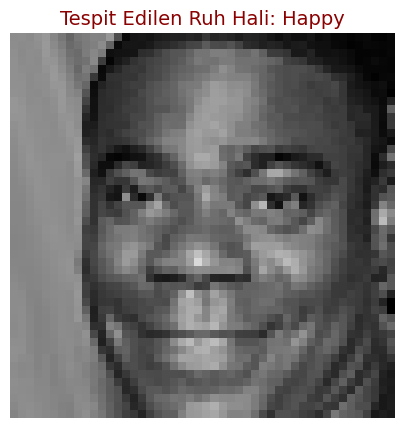

🎬 MODUNUZA UYGUN FİLM ÖNERİSİ (Happy)
📌 FİLM ADI: The Lord of the Rings: The Return of the King
🌟 IMDB PUANI: 8.9
🎭 TÜR: Action, Adventure, Drama
📖 ÖZET: Gandalf and Aragorn lead the World of Men against Sauron's army to draw his gaze from Frodo and Sam as they approach Mount Doom with the One Ring.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

imdb_path = r'C:\Users\efeya\Desktop\DerinFinal\imdb_top_1000.csv'
imdb_df = pd.read_csv(imdb_path)

model.load_state_dict(torch.load('best_squeezenet_emotion_v2.pth', weights_only=True))
model.eval()

emotion_to_genre = {
    'Happy': 'Comedy|Animation|Adventure', 
    'Sad': 'Drama|Romance',                
    'Angry': 'Action|Crime|War',           
    'Fear': 'Horror|Thriller',             
    'Disgust': 'Thriller|Crime',           
    'Surprise': 'Mystery|Sci-Fi|Fantasy',  
    'Neutral': 'Documentary|Biography'     
}

def get_movie_recommendation(predicted_emotion, df):
    target_genres = emotion_to_genre.get(predicted_emotion, 'Drama')
    filtered = df[df['Genre'].str.contains(target_genres, case=False, na=False)]
    if not filtered.empty:
        return filtered.sort_values(by='IMDB_Rating', ascending=False).iloc[0]
    return None

def predict_and_recommend(image_path):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_emotion = classes[pred[0]]
    
    movie = get_movie_recommendation(predicted_emotion, imdb_df)
    
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.title(f"Tespit Edilen Ruh Hali: {predicted_emotion}", fontsize=14, color='darkred')
    plt.axis('off')
    plt.show()
    
    if movie is not None:
        print("="*60)
        print(f"🎬 MODUNUZA UYGUN FİLM ÖNERİSİ ({predicted_emotion})")
        print(f"📌 FİLM ADI: {movie['Series_Title']}")
        print(f"🌟 IMDB PUANI: {movie['IMDB_Rating']}")
        print(f"🎭 TÜR: {movie['Genre']}")
        print(f"📖 ÖZET: {movie['Overview']}")
        print("="*60)
    else:
        print("Uygun bir film önerisi bulunamadı.")

test_resmi = r'C:\Users\efeya\Desktop\DerinFinal\Data\archive\test\happy\PrivateTest_95094.jpg'
predict_and_recommend(test_resmi)

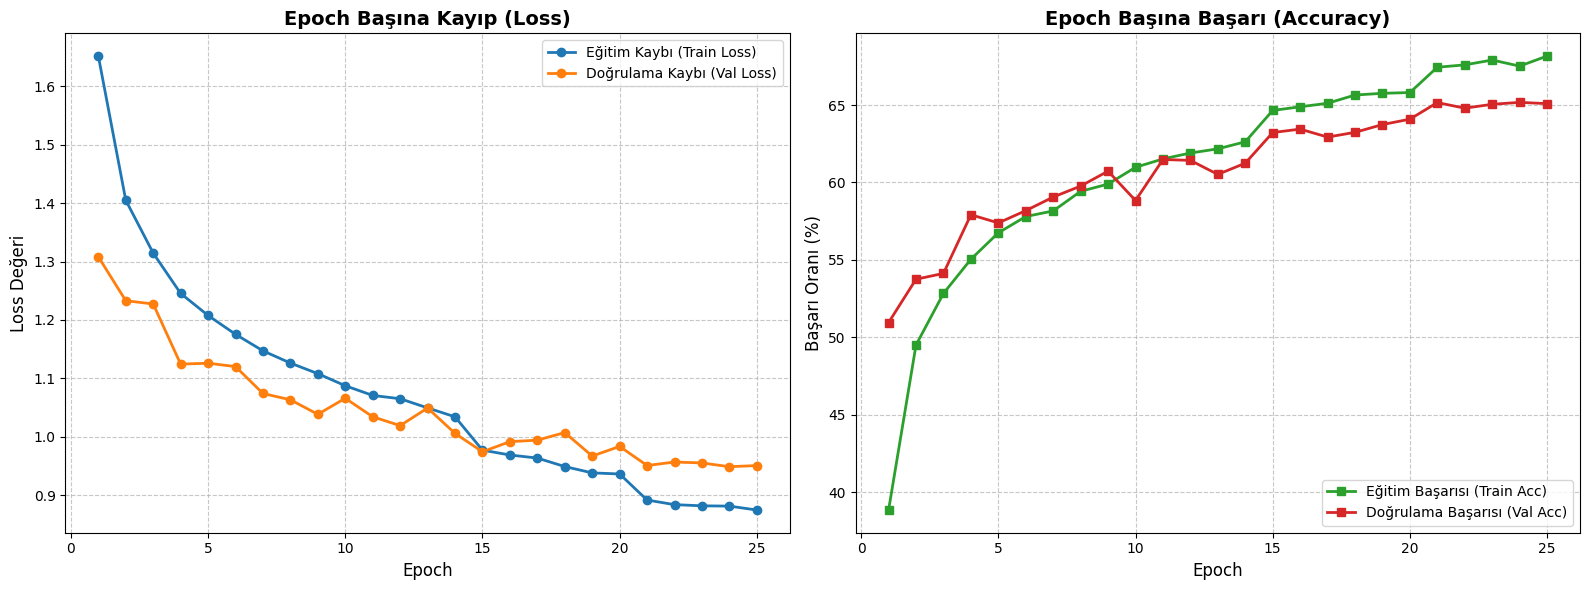

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Eğitim Kaybı (Train Loss)', color='#1f77b4', marker='o', linewidth=2)
    plt.plot(epochs_range, history['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='#ff7f0e', marker='o', linewidth=2)
    plt.title('Epoch Başına Kayıp (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss Değeri', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Eğitim Başarısı (Train Acc)', color='#2ca02c', marker='s', linewidth=2)
    plt.plot(epochs_range, history['val_acc'], label='Doğrulama Başarısı (Val Acc)', color='#d62728', marker='s', linewidth=2)
    plt.title('Epoch Başına Başarı (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Başarı Oranı (%)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
plot_training_history(history)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns

def get_all_preds_and_probas(model, loader):
    all_preds = []
    all_labels = []
    all_probas = []
    
    model.eval()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            probas = torch.softmax(outputs, dim=1)
            
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probas)

y_true, y_pred, y_probas = get_all_preds_and_probas(model, val_loader)

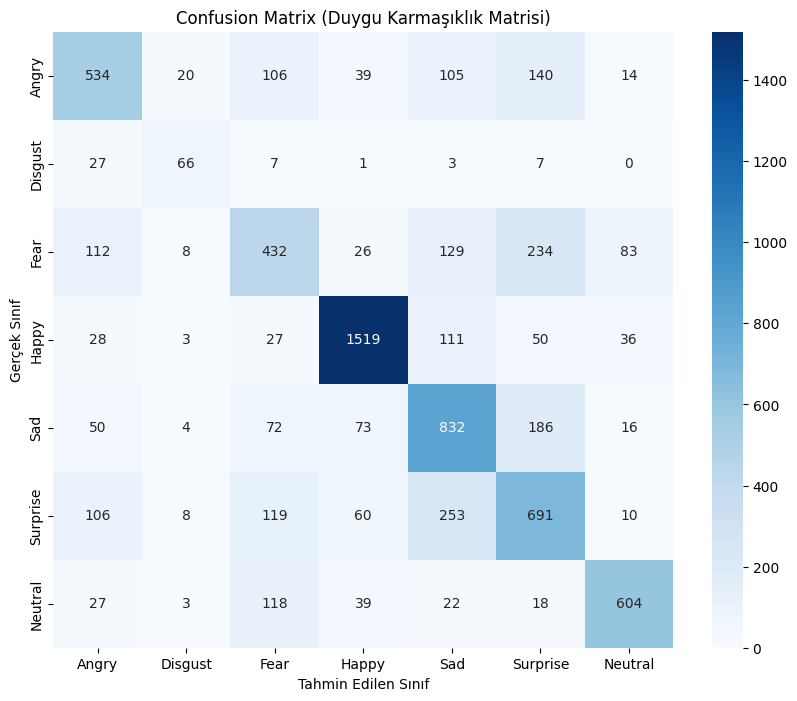

In [35]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (Duygu Karmaşıklık Matrisi)')
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.show()

plot_confusion_matrix(y_true, y_pred, classes)

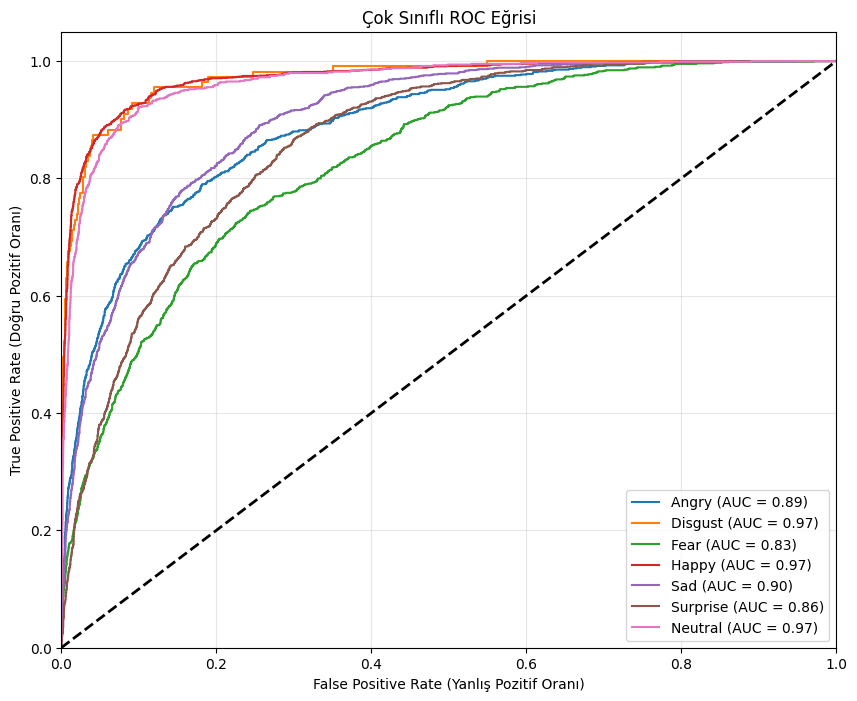

In [ ]:
def plot_multiclass_roc(y_true, y_probas, classes):
    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    n_classes = len(classes)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    plt.figure(figsize=(10, 8))
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probas[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
    plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
    plt.title('Çok Sınıflı ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plot_multiclass_roc(y_true, y_probas, classes)